In [24]:
import rawpy
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
from imageio import imwrite
from astropy.io import fits
import pandas as pd
import imageio
from fractions import Fraction

In [27]:
def load_raw_image(path, normalize=True):
    try:
        with rawpy.imread(path) as raw:
            rgb = raw.postprocess(
                use_camera_wb=True,
                no_auto_bright=True,
                output_bps=16
            )
        image = rgb.astype(np.float32)
        if normalize:
            image /= 65535.0  # normalize to [0, 1]
        return image
    except rawpy.LibRawFileUnsupportedError:
        print(f"LibRawFileUnsupportedError: Skipping {path}")
        return None
    except Exception as e:
        print(f"⚠️ Problem reading {path}: {e}")
        return None

def load_image_stack(folder):
    sum_image = None
    count = 0
    for file in tqdm(sorted(os.listdir(folder))):
        if file.lower().endswith(('.cr2', '.nef', '.arw', '.dng', '.rw2', '.raf', '.cr3', '.png')):
            try:
                img = load_raw_image(os.path.join(folder, file))
                print(f'{img.shape}')
                
                #if img.shape != (6246, 4170, 3):
                if img.shape!= (3870, 5796, 3): 
                    img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
                    print(f"Skipping (not full RAW): {file} with shape {img.shape}")
                    #continue
                
                if sum_image is None:
                    sum_image = np.zeros_like(img)
    
                if img.shape != sum_image.shape:
                    raise ValueError(f"Shape mismatch: {img.shape} vs {sum_image.shape}")
                sum_image += img
                count += 1
            except Exception as e:
                print(f"⚠️ Problem with {file}: {e}")

                
    return sum_image / count if count > 0 else None

def calibrate_image(light, dark_stack, flat_stack):
    try:
        epsilon = 1e-6 #prevent division by 0
        safe_flat = np.where(flat_stack < epsilon, epsilon, flat_stack)
        calibrated = (light - dark_stack) / safe_flat
        calibrated = np.clip(calibrated, 0, 1) #normalize between 0-1
    except Exception as e:
        print('Attempting to rotate an image') #Checks for images rotated incorrectly
        light = cv2.rotate(light, cv2.ROTATE_90_CLOCKWISE)
        epsilon = 1e-6
        safe_flat = np.where(flat_stack < epsilon, epsilon, flat_stack)
        calibrated = (light - dark_stack) / safe_flat
        calibrated = np.clip(calibrated, 0, 1)
    return calibrated

def getExposureTime(im_name, obs_name):
    #/media/gsr/Seagate Por/EdEon/Observatories/R_7Pc9Yj1CmydXAMu
    # path = '/media/gsr/Seagate Por/EdEon/Observatories'
    path = '/Volumes/Seagate Por/EdEon/Observatories'
    csv = f'{path}/out2.csv'
    df = pd.read_csv(csv)
    
    for index, row in df.iterrows():
        if row.iloc[0] == observatory and row.iloc[1] == im_name:
            return float(Fraction(row.iloc[-16]))

In [31]:
import os

print("Bias files:", os.listdir(bias)[:5])
print("Dark files:", os.listdir(darks)[:5])
print("Flat files:", os.listdir(flats)[:5])
print("Light files:", os.listdir(lights)[:5])

Bias files: ['20240408-JJ6A9894.CR2', '._20240408-JJ6A9894.CR2', '20240408-JJ6A9895.CR2', '._20240408-JJ6A9895.CR2', '20240408-JJ6A9896.CR2']
Dark files: ['20240408-JJ6A0001.CR2', '._20240408-JJ6A0001.CR2', '20240408-JJ6A0002.CR2', '._20240408-JJ6A0002.CR2', '20240408-JJ6A0003.CR2']
Flat files: ['20240408-JJ6A0356.CR2', '._20240408-JJ6A0356.CR2', '20240408-JJ6A0357.CR2', '._20240408-JJ6A0357.CR2', '20240408-JJ6A0358.CR2']
Light files: ['20240408-JJ6A9558.CR2', '._20240408-JJ6A9558.CR2', '20240408-JJ6A9559.CR2', '._20240408-JJ6A9559.CR2', '20240408-JJ6A9560.CR2']


In [30]:
# path ='/media/gsr/Seagate Portable Drive/EM_Level2_Observatories'
#/media/gsr/Seagate Por/EdEon/Observatories/R_1zdrnQVQUkXDHOV
# /Volumes/Seagate2/Criteria/R_7CIeMKVx5vq880l
path= '/Volumes/Seagate2/Criteria'
observatory = 'R_7r0wMEX4PAfIzZy'
#''/Volumes/Seagate Por/EdEon/Observatories/R_6E47wteQIIxSlKB/Light/Martin_Curic_Totality'
lights = f'{path}/{observatory}/Light'
darks = f'{path}/{observatory}/Dark'
bias = f'{path}/{observatory}/Bias'
flats = f'{path}/{observatory}/Flat'

print("Stacking Bias... 📚")
bias_stack = load_image_stack(bias)
print(type(bias_stack))
#add bias save

print("Stacking Darks... 📚")
dark_stack = load_image_stack(darks) - bias_stack 
#add dark save

print("Stacking Flats... 📚")
flat_stack = load_image_stack(flats) - bias_stack
flat_stack /= np.median(flat_stack)
#add flat save


print("Calibrating... ✏️")
for img in tqdm(os.listdir(f'{lights}')):
    light = load_raw_image(f'{lights}/{img}')
    if light is None or dark_stack is None or flat_stack is None:
        print(f"Skipping calibration for {img} due to missing data (light, dark, or flat).")
        continue
    calibrated = calibrate_image(light, dark_stack, flat_stack)
    
    #fits
    fits_data = calibrated.astype(np.float32)
    im_name = img.split('.')[0] + '.fits'
    hdu = fits.PrimaryHDU(fits_data)
    hdu.header['EXPTIME'] = getExposureTime(img, observatory)

    hdu.writeto(f'{path}/{observatory}/Fits/{im_name}', overwrite=True)
    
print("✅ Calibration complete!")

Stacking Bias... 📚


 12%|█████████████████████▋                                                                                                                                                       | 5/40 [00:00<00:00, 48.89it/s]

LibRawFileUnsupportedError: Skipping /Volumes/Seagate2/Criteria/R_7r0wMEX4PAfIzZy/Bias/._20240408-JJ6A9894.CR2
⚠️ Problem with ._20240408-JJ6A9894.CR2: 'NoneType' object has no attribute 'shape'
LibRawFileUnsupportedError: Skipping /Volumes/Seagate2/Criteria/R_7r0wMEX4PAfIzZy/Bias/._20240408-JJ6A9895.CR2
⚠️ Problem with ._20240408-JJ6A9895.CR2: 'NoneType' object has no attribute 'shape'
LibRawFileUnsupportedError: Skipping /Volumes/Seagate2/Criteria/R_7r0wMEX4PAfIzZy/Bias/._20240408-JJ6A9896.CR2
⚠️ Problem with ._20240408-JJ6A9896.CR2: 'NoneType' object has no attribute 'shape'
LibRawFileUnsupportedError: Skipping /Volumes/Seagate2/Criteria/R_7r0wMEX4PAfIzZy/Bias/._20240408-JJ6A9897.CR2
⚠️ Problem with ._20240408-JJ6A9897.CR2: 'NoneType' object has no attribute 'shape'
LibRawFileUnsupportedError: Skipping /Volumes/Seagate2/Criteria/R_7r0wMEX4PAfIzZy/Bias/._20240408-JJ6A9898.CR2
⚠️ Problem with ._20240408-JJ6A9898.CR2: 'NoneType' object has no attribute 'shape'
LibRawFileUnsupportedErro

 52%|██████████████████████████████████████████████████████████████████████████████████████████▎                                                                                 | 21/40 [00:02<00:02,  6.75it/s]

(3870, 5796, 3)
(3870, 5796, 3)
(3870, 5796, 3)


...

LibRawFileUnsupportedError: Skipping /Volumes/Seagate2/Criteria/R_7r0wMEX4PAfIzZy/Light/._20240408-JJ6A9602.CR2
Skipping calibration for ._20240408-JJ6A9602.CR2 due to missing data (light, dark, or flat).


/var/folders/40/vth_4pfn21j_lc91cbcd_qs40000gn/T/ipykernel_20337/3804490031.py:69: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv)
 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎   | 92/94 [05:10<00:05,  2.78s/it]

LibRawFileUnsupportedError: Skipping /Volumes/Seagate2/Criteria/R_7r0wMEX4PAfIzZy/Light/._20240408-JJ6A9603.CR2
Skipping calibration for ._20240408-JJ6A9603.CR2 due to missing data (light, dark, or flat).


/var/folders/40/vth_4pfn21j_lc91cbcd_qs40000gn/T/ipykernel_20337/3804490031.py:69: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv)
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 94/94 [05:16<00:00,  3.37s/it]

LibRawFileUnsupportedError: Skipping /Volumes/Seagate2/Criteria/R_7r0wMEX4PAfIzZy/Light/._20240408-JJ6A9604.CR2
Skipping calibration for ._20240408-JJ6A9604.CR2 due to missing data (light, dark, or flat).
✅ Calibration complete!


In [21]:
def load_raw_image(path, normalize=True):
    # Handle PNG files separately
    if path.lower().endswith('.png'):
        try:
            from PIL import Image
            # or use: import cv2; image = cv2.imread(path, cv2.IMREAD_UNCHANGED)
            img = Image.open(path)
            image = np.array(img).astype(np.float32)
            if normalize and image.max() > 1:
                image /= image.max()  # normalize to [0, 1]
            return image
        except Exception as e:
            print(f"⚠️ Problem reading PNG {path}: {e}")
            return None
    
    # Handle RAW files (CR2, NEF, ARW, etc.)
    try:
        with rawpy.imread(path) as raw:
            rgb = raw.postprocess(
                use_camera_wb=True,
                no_auto_bright=True,
                output_bps=16
            )
        image = rgb.astype(np.float32)
        if normalize:
            image /= 65535.0  # normalize to [0, 1]
        return image
    except rawpy.LibRawFileUnsupportedError:
        print(f"LibRawFileUnsupportedError: Skipping {path}")
        return None
    except Exception as e:
        print(f"⚠️ Problem reading {path}: {e}")
        return None

def getExposureTime(im_name, obs_name):
    path = '/Volumes/Seagate Por/EdEon/Observatories'
    csv = f'{path}/out.csv'
    df = pd.read_csv(csv)
    
    for index, row in df.iterrows():
        if row.iloc[2] == observatory and row.iloc[0] == im_name:
            exposure_value = row.iloc[-4]
            
            # Check if the value is NaN or empty
            if pd.isna(exposure_value) or exposure_value == '':
                print(f"⚠️ Warning: No exposure time found for {im_name}")
                return None
            
            try:
                return float(Fraction(exposure_value))
            except (ValueError, ZeroDivisionError, TypeError) as e:
                print(f"⚠️ Warning: Invalid exposure time '{exposure_value}' for {im_name}: {e}")
                return None
    
    # If no matching row found
    print(f"⚠️ Warning: No metadata found for {im_name} in {obs_name}")
    return None

In [24]:
path = '/Volumes/Seagate Por/EdEon/Observatories'
observatory = 'R_3wIQNCVwjL0Pcxb'
#'/Volumes/Seagate Por/EdEon/Observatories/R_5ktbk8cP73VRz0J'
lights = f'{path}/{observatory}/Lights'
print("Calibrating... ✏️")
for img in tqdm(os.listdir(f'{lights}')):
    if img.lower().endswith(('.cr2', '.nef', '.arw', '.dng', '.rw2', '.raf', '.cr3', '.png')):
        light = load_raw_image(f'{lights}/{img}')
        
        if light is None:
            print(f"  Skipping {img} (not a readable RAW file)")
            continue
        
        # Everything below here MUST be indented at this level
        # This code only runs if light is NOT None
        fits_data = light.astype(np.float32)
        im_name = img.split('.')[0] + '.fits'
        hdu = fits.PrimaryHDU(fits_data)
        
        exptime = getExposureTime(img, observatory)
        if exptime is not None:
            hdu.header['EXPTIME'] = exptime
        else:
            hdu.header['EXPTIME'] = 1.0  # default value
        
        hdu.writeto(f'{path}/{observatory}/Fits/{im_name}', overwrite=True)

print("✅ Calibration complete!")

Calibrating... ✏️


  0%|                                                                                                             | 0/15 [00:00<?, ?it/s]

⚠️ Warning: No exposure time found for Shawn_Connelly_20240408-1513.19-mod.png


  7%|██████▋                                                                                              | 1/15 [00:10<02:30, 10.77s/it]

⚠️ Warning: No exposure time found for Shawn_Connelly_20240408-1513.23-A-mod.png


...

⚠️ Warning: No exposure time found for Shawn_Connelly_20240408-1514.39-A-mod.png


 87%|██████████████████████████████████████████████████████████████████████████████████████▋             | 13/15 [01:49<00:14,  7.11s/it]

⚠️ Warning: No exposure time found for Shawn_Connelly_20240408.1514.41 - Solar Eclipse - totality - 600mm - HDR mean stack-final.png


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [02:01<00:00,  8.08s/it]

✅ Calibration complete!


In [6]:
#loading light images
#'/media/gsr/Seagate Por/EdEon/Observatories/R_2e8q4qlTRwWkqMR'
path = '/media/gsr/Seagate Por/EdEon/Observatories/'
observatory = 'R_2e8q4qlTRwWkqMR'
#'/Volumes/Seagate Por/EdEon/Observatories/R_5ktbk8cP73VRz0J'
lights = f'{path}/{observatory}/Light'
print("Calibrating... ✏️")
for img in tqdm(os.listdir(f'{lights}')):
    
        light = load_raw_image(f'{lights}/{img}')

        #fits
        fits_data = light.astype(np.float32)
        im_name = img.split('.')[0] + '.fits'
        hdu = fits.PrimaryHDU(fits_data)
        hdu.header['EXPTIME'] = getExposureTime(img, observatory)
    
        hdu.writeto(f'{path}/{observatory}/Fits/{im_name}', overwrite=True)
    
print("✅ Calibration complete!")

Calibrating... ✏️


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35/35 [01:31<00:00,  2.62s/it]

✅ Calibration complete!


Image shape: (4016, 6016, 3)
Saved /media/gsr/Seagate Por/EdEon/Observatories/R_7CJbmiOaesRpo3u/FitsNull/DSC_0036.png
Image shape: (4016, 6016, 3)
Saved /media/gsr/Seagate Por/EdEon/Observatories/R_7CJbmiOaesRpo3u/FitsNull/DSC_0037.png
Image shape: (4016, 6016, 3)
Saved /media/gsr/Seagate Por/EdEon/Observatories/R_7CJbmiOaesRpo3u/FitsNull/DSC_0042.png
Image shape: (4016, 6016, 3)
Saved /media/gsr/Seagate Por/EdEon/Observatories/R_7CJbmiOaesRpo3u/FitsNull/DSC_0044.png
Image shape: (4016, 6016, 3)
Saved /media/gsr/Seagate Por/EdEon/Observatories/R_7CJbmiOaesRpo3u/FitsNull/DSC_0045.png
Image shape: (4016, 6016, 3)
Saved /media/gsr/Seagate Por/EdEon/Observatories/R_7CJbmiOaesRpo3u/FitsNull/DSC_0046.png
Image shape: (4016, 6016, 3)
Saved /media/gsr/Seagate Por/EdEon/Observatories/R_7CJbmiOaesRpo3u/FitsNull/DSC_0047.png
Image shape: (4016, 6016, 3)
Saved /media/gsr/Seagate Por/EdEon/Observatories/R_7CJbmiOaesRpo3u/FitsNull/DSC_0049.png
Image shape: (4016, 6016, 3)
Saved /media/gsr/Seagate Po

KeyboardInterrupt: 

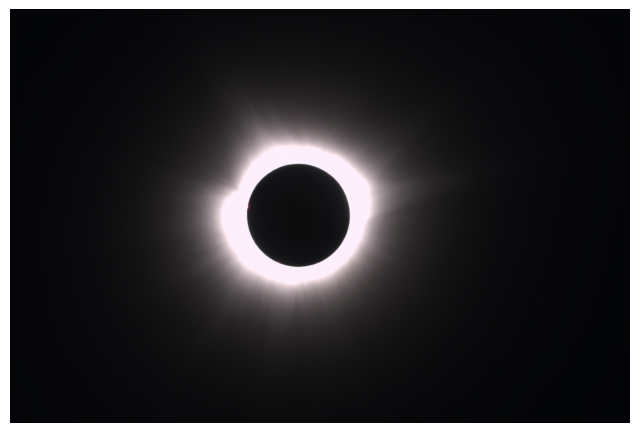

In [16]:
#'/Volumes/Seagate Por/EdEon/Observatories/R_1yVFawatWSRzbIR'

import os
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

fits_folder = '/media/gsr/Seagate Por/EdEon/Observatories/R_7CJbmiOaesRpo3u/Fits'
png_folder = '/media/gsr/Seagate Por/EdEon/Observatories/R_7CJbmiOaesRpo3u/FitsNull'

os.makedirs(png_folder, exist_ok=True)

for file in os.listdir(fits_folder):
    if not file.lower().endswith('.fits'):
        continue
    file_path = os.path.join(fits_folder, file)
    try:
        with fits.open(file_path) as hdul:
            data = hdul[0].data
            header = hdul[0].header
    except Exception as e:
        print(f"Error reading {file}: {e}")
        continue

    if data is None:
        print(f"No data in {file}")
        continue

    print(f"Image shape: {data.shape}")

    # Normalize (robust scaling)
    vmin, vmax = np.percentile(data[np.isfinite(data)], (1, 99))
    plt.figure(figsize=(8, 8))
    plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    plt.axis('off')

    # Save PNG
    base = os.path.splitext(file)[0]
    png_path = os.path.join(png_folder, f"{base}.png")
    plt.savefig(png_path, bbox_inches='tight', pad_inches=0)
    plt.close()
    print(f"Saved {png_path}")